# Stream Mining and Drift
Inspect split-level drift and low-truth trend signals.

In [9]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')
proc = Path('../data/processed')

In [10]:
drift = pd.read_csv(proc / 'stream_drift_summary.csv')
drift.sort_values('js_divergence', ascending=False)

,split_a,split_b,feature,js_divergence
5,valid,test,state_clean,0.006294
8,train,test,state_clean,0.004755
2,train,valid,state_clean,0.004633
3,valid,test,label,0.001812
0,train,valid,label,0.001541
4,valid,test,party_grouped,0.000934
1,train,valid,party_grouped,0.000913
6,train,test,label,0.000174
7,train,test,party_grouped,0.000121


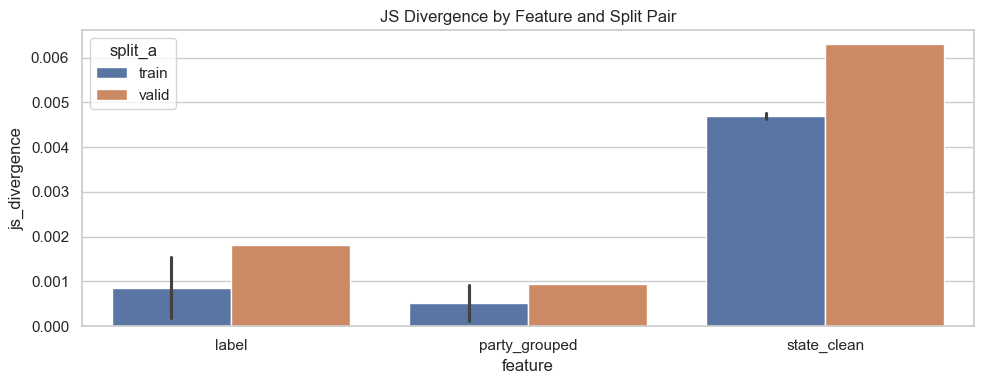

In [11]:
plt.figure(figsize=(10,4))
sns.barplot(data=drift, x='feature', y='js_divergence', hue='split_a')
plt.title('JS Divergence by Feature and Split Pair')
plt.tight_layout()
plt.show()

In [12]:
lt = pd.read_csv(proc / 'stream_low_truth_rate.csv')
lt

,split,low_truth_rate
0,test,0.436464
1,train,0.438281
2,valid,0.479751


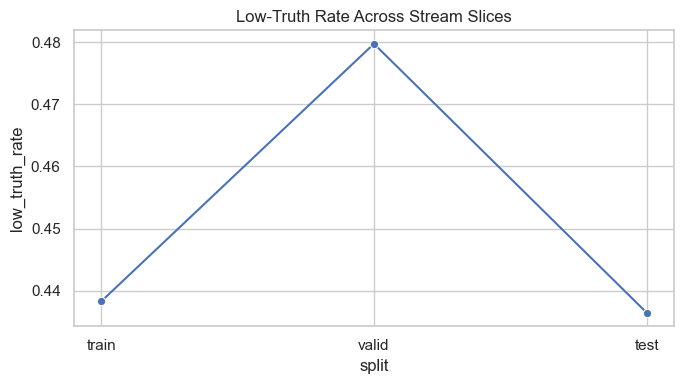

In [13]:
plt.figure(figsize=(7,4))
order = ['train','valid','test']
lt['split'] = pd.Categorical(lt['split'], categories=order, ordered=True)
lt = lt.sort_values('split')
sns.lineplot(data=lt, x='split', y='low_truth_rate', marker='o')
plt.title('Low-Truth Rate Across Stream Slices')
plt.tight_layout()
plt.show()

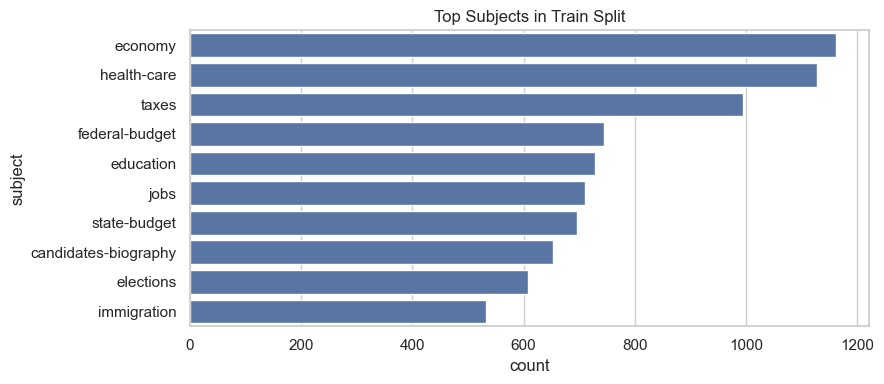

In [14]:
subjects = pd.read_csv(proc / 'stream_top_subjects.csv')
top_train = subjects[subjects['split']=='train'].head(10)
plt.figure(figsize=(9,4))
sns.barplot(data=top_train, x='count', y='subject')
plt.title('Top Subjects in Train Split')
plt.tight_layout()
plt.show()